<a href="https://colab.research.google.com/github/AtharvRai67/task-6/blob/main/taskk9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Project: House Price Prediction

Day 1: Understand the Data

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading dataset
from google.colab import files
uploaded = files.upload()

Saving house_prices (2).csv to house_prices (2).csv


In [4]:
df = pd.read_csv('house_prices (2).csv')

# Basic info
print(df.head())
print(df.info())
print(df.describe())

  Property_ID  Area  Bedrooms  Bathrooms  Age     Location Property_Type  \
0    PROP0001  3712         4          3   36        Rural         House   
1    PROP0002  1591         4          1   35       Suburb         House   
2    PROP0003  1646         4          3   20        Rural         Villa   
3    PROP0004  4814         1          2   13  City Center         Villa   
4    PROP0005   800         4          2   38       Suburb     Apartment   

      Price  
0  22260000  
1  16057500  
2  12730000  
3  50840000  
4  10650000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Proper

In [6]:
#Missing Values in Each Column
df.isnull().sum()

,0
Property_ID,0
Area,0
Bedrooms,0
Bathrooms,0
Age,0
Location,0
Property_Type,0
Price,0


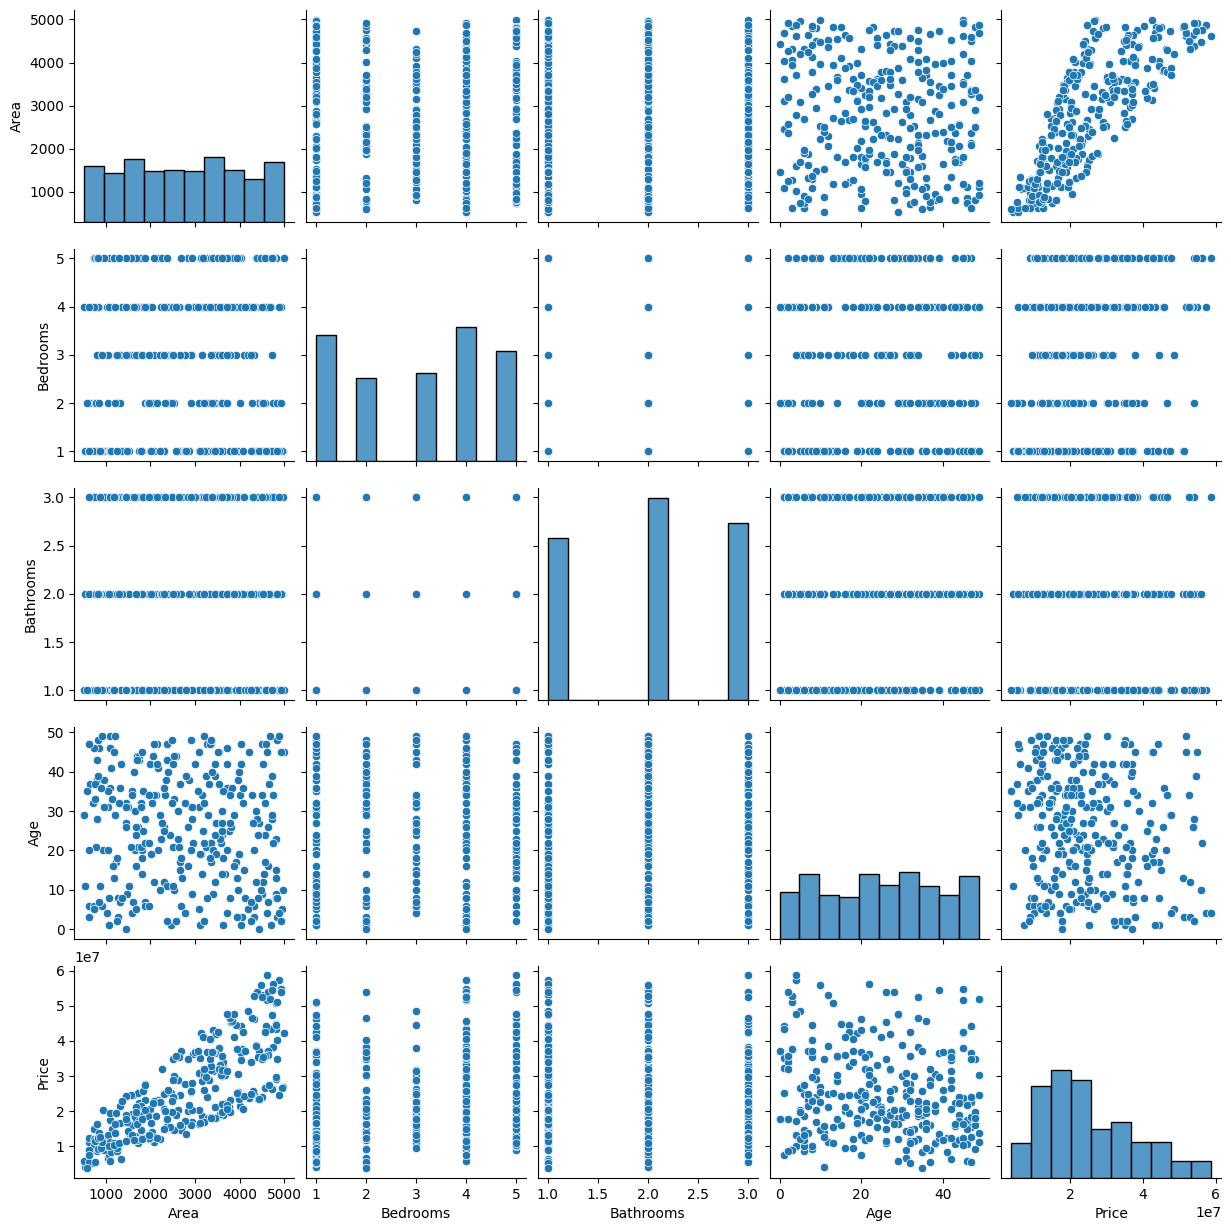

In [5]:
#Visualize Relationships
sns.pairplot(df)
plt.show()

DAY 2 : Data Preparation


In [13]:
# Handle missing values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_291/1423683053.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [25]:
# Convert categorical to numeric
# Drop 'Property_ID' as it's a unique identifier and not a predictive feature
if 'Property_ID' in df.columns:
    df = df.drop('Property_ID', axis=1)
df = pd.get_dummies(df, drop_first=True)

# Drop any remaining Property_ID_XXXX columns that might have been created due to prior runs
# This addresses potential multicollinearity from unique identifiers being one-hot encoded.
prop_id_cols = [col for col in df.columns if col.startswith('Property_ID_')]
if prop_id_cols:
    df = df.drop(columns=prop_id_cols)

# Define X and y
X = df.drop('Price', axis=1)
y = df['Price']

In [19]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data prepared successfully!")

Data prepared successfully!


Day 3: Build First Model

In [21]:
#Linear Regression (From Scratch)
import numpy as np

class LinearRegressionScratch:

    def fit(self, X, y):
        # Add bias column (1s)
        ones = np.ones((X.shape[0], 1))
        X = np.hstack((ones, X))

        # Apply Normal Equation
        self.theta = np.linalg.inv(X.T @ X) @ X.T @ y

    def predict(self, X):
        # Add bias column
        ones = np.ones((X.shape[0], 1))
        X = np.hstack((ones, X))

        return X @ self.theta

In [28]:
# Linear Regression from Scratch Implementation
import numpy as np

class LinearRegressionScratch:
    def fit(self, X, y):
        # Add bias (intercept) term to X
        # This adds a column of ones to the left of the feature matrix
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack((ones, X))

        # Calculate coefficients (theta) using the Normal Equation:
        # theta = (X_b.T @ X_b)^-1 @ X_b.T @ y
        # (X_b.T @ X_b) is the matrix (X_transpose * X)
        # np.linalg.inv() calculates the inverse of a matrix
        # @ is the matrix multiplication operator
        self.theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

    def predict(self, X):
        # Add bias (intercept) term to X for prediction
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack((ones, X))

        # Calculate predictions: y_pred = X_b @ theta
        return X_b @ self.theta

Day 4: Train with scikit-learn

In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [31]:
# Import required libraries
from sklearn.linear_model import LinearRegression

# 1. Create the model
model = LinearRegression()

# 2. Fit (train) the model using training data
model.fit(X_train, y_train)

# 3. Make predictions on test data
predictions = model.predict(X_test)

# 4. Print first few predictions
print("Predicted Prices:", predictions[:5])

Predicted Prices: [16027440.58835226 18916367.2362597  48016549.68941486 27401189.53880025
 22207756.38956505]


Day 5: Evaluate Model

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

MAE: 2356914.2878653887
MSE: 9321646434831.658
R²: 0.9345471804672836


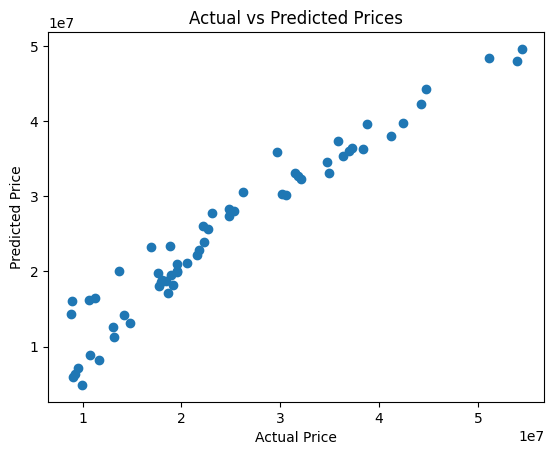

In [33]:
#Visualization
plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

Day 6: Improve Model

In [34]:
#Polynomial Features
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

LinearRegression()

In [35]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [36]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Day 7: Interpret & Present

In [37]:
feature_names = poly.get_feature_names_out(X.columns)

# Create a DataFrame to display coefficients with their corresponding feature names
coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
})

print("Model Intercept:", model.intercept_)
print("\nModel Coefficients:")
print(coefficients_df.to_string()) # Use to_string() to avoid truncation

Model Intercept: -0.012626178562641144

Model Coefficients:
                                    Feature   Coefficient
0                                         1  1.265586e-02
1                                      Area  1.000000e+04
2                                  Bedrooms  2.000000e+06
3                                 Bathrooms  1.000000e+06
4                                       Age -1.000000e+05
5                            Location_Rural  5.637308e-04
6                           Location_Suburb -2.651664e-04
7                       Property_Type_House  1.680721e-04
8                       Property_Type_Villa  5.595943e-05
9                                    Area^2  1.916172e-12
10                            Area Bedrooms -3.410863e-10
11                           Area Bathrooms  3.725633e-10
12                                 Area Age -8.357254e-10
13                      Area Location_Rural -5.000000e+03
14                     Area Location_Suburb -2.500000e+03
15          

In [39]:
# Evaluate Decision Tree Model
print("\n--- Decision Tree Model Performance ---")
mae_dt = mean_absolute_error(y_test, dt_pred)
mse_dt = mean_squared_error(y_test, dt_pred)
r2_dt = r2_score(y_test, dt_pred)

print(f"MAE (Decision Tree): {mae_dt:.2f}")
print(f"MSE (Decision Tree): {mse_dt:.2f}")
print(f"R² (Decision Tree): {r2_dt:.4f}")


--- Decision Tree Model Performance ---
MAE (Decision Tree): 2312958.33
MSE (Decision Tree): 8294489270833.33
R² (Decision Tree): 0.9418


In [40]:
# Evaluate Random Forest Model
print("\n--- Random Forest Model Performance ---")
mae_rf = mean_absolute_error(y_test, rf_pred)
mse_rf = mean_squared_error(y_test, rf_pred)
r2_rf = r2_score(y_test, rf_pred)

print(f"MAE (Random Forest): {mae_rf:.2f}")
print(f"MSE (Random Forest): {mse_rf:.2f}")
print(f"R² (Random Forest): {r2_rf:.4f}")


--- Random Forest Model Performance ---
MAE (Random Forest): 1865662.92
MSE (Random Forest): 6106877473197.92
R² (Random Forest): 0.9571


### Model Performance Comparison

Let's put all the model evaluation metrics together to compare them.

                Model          MAE          MSE  R2 Score
Polynomial Regression 2.356914e+06 9.321646e+12  0.934547
        Decision Tree 2.312958e+06 8.294489e+12  0.941759
        Random Forest 1.865663e+06 6.106877e+12  0.957120


/tmp/ipykernel_291/1369630330.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=performance_df, palette='viridis')


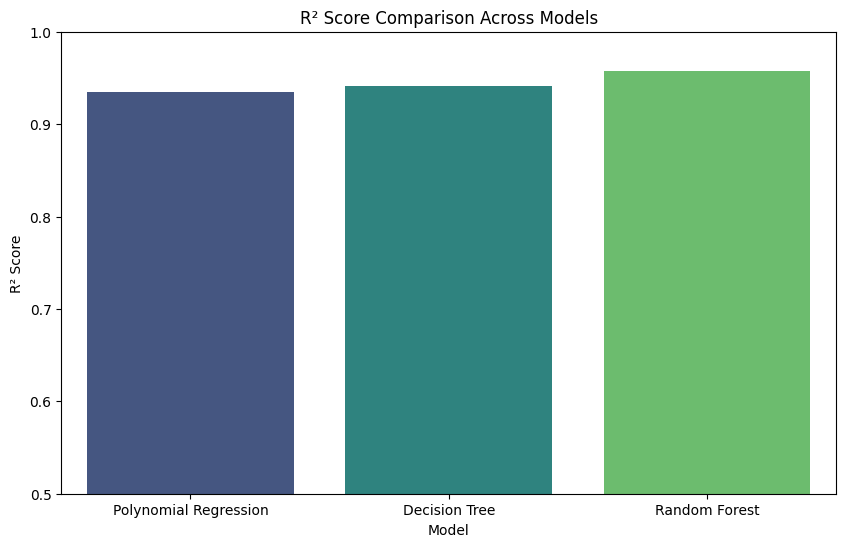

In [41]:
performance_data = {
    'Model': ['Polynomial Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [mae, mae_dt, mae_rf],
    'MSE': [mse, mse_dt, mse_rf],
    'R2 Score': [r2, r2_dt, r2_rf]
}

performance_df = pd.DataFrame(performance_data)
print(performance_df.to_string(index=False))

# Visualize the R2 Scores
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=performance_df, palette='viridis')
plt.title('R² Score Comparison Across Models')
plt.ylabel('R² Score')
plt.ylim(0.5, 1.0) # Set a reasonable y-limit for R2
plt.show()

### Interpretation of Results

Based on the R² scores, we can see that all three models performed very well on this dataset, with R² values close to 1, indicating a strong fit to the data.

*   **Random Forest** achieved the highest R² score, suggesting it is the best performing model among the three for this particular dataset, capturing the most variance in house prices.
*   **Polynomial Regression** also showed excellent performance, indicating that the polynomial features significantly improved the linear model's ability to fit non-linear relationships.
*   **Decision Tree** performed slightly worse than Random Forest but still provided a good fit.

The low MAE and MSE values across all models further confirm their good predictive accuracy, with Random Forest again leading in minimizing absolute and squared errors.

In [38]:
# Sort features by the absolute value of their coefficients to identify the most important ones
important_features = coefficients_df.reindex(coefficients_df['Coefficient'].abs().sort_values(ascending=False).index)

print("\nTop Important Features (sorted by absolute coefficient value):")
print(important_features.head(10).to_string())


Top Important Features (sorted by absolute coefficient value):
                      Feature   Coefficient
2                    Bedrooms  2.000000e+06
3                   Bathrooms  1.000000e+06
20    Bedrooms Location_Rural -1.000000e+06
21   Bedrooms Location_Suburb -5.000000e+05
26   Bathrooms Location_Rural -5.000000e+05
27  Bathrooms Location_Suburb -2.500000e+05
4                         Age -1.000000e+05
31         Age Location_Rural  5.000000e+04
32        Age Location_Suburb  2.500000e+04
1                        Area  1.000000e+04
